# Image Classification using CNN — CIFAR-10

| | |
|---|---|
| **Name** | Ayush Ranjan |
| **Roll No** | 23MIP10135 |
| **Institute** | VIT Bhopal |
| **Dataset** | [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) (also at [Kaggle](https://www.kaggle.com/c/cifar-10)) |

**Objective:** Classify 32×32 colour images into 10 object categories using a deep CNN.
**Classes:** airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
**Dataset size:** 60,000 images (50,000 train + 10,000 test)


## Step 1: Install Libraries


In [1]:
!pip install tensorflow scikit-learn matplotlib seaborn numpy -q
print('Libraries ready!')

Libraries ready!


## Step 2: Imports


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dense, Dropout,
                                      BatchNormalization, GlobalAveragePooling2D,
                                      Flatten)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)
print(f'TensorFlow {tf.__version__} | GPU: {tf.config.list_physical_devices("GPU")}')

TensorFlow 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 3: Load CIFAR-10 Dataset


In [5]:
!pip install datasets -q

from datasets import load_dataset
import numpy as np

print("Downloading CIFAR-10 from Hugging Face...")
ds = load_dataset("uoft-cs/cifar10")

X_train = np.array(ds['train']['img'])      # (50000, 32, 32, 3)
y_train = np.array(ds['train']['label'])    # (50000,)
X_test  = np.array(ds['test']['img'])       # (10000, 32, 32, 3)
y_test  = np.array(ds['test']['label'])     # (10000,)

CLASS_NAMES = ds['train'].features['label'].names
NUM_CLASSES = len(CLASS_NAMES)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Classes ({NUM_CLASSES}): {list(CLASS_NAMES)}')

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Train: (50000, 32, 32, 3)  |  Test: (10000, 32, 32, 3)
Classes (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Step 4: Explore Dataset


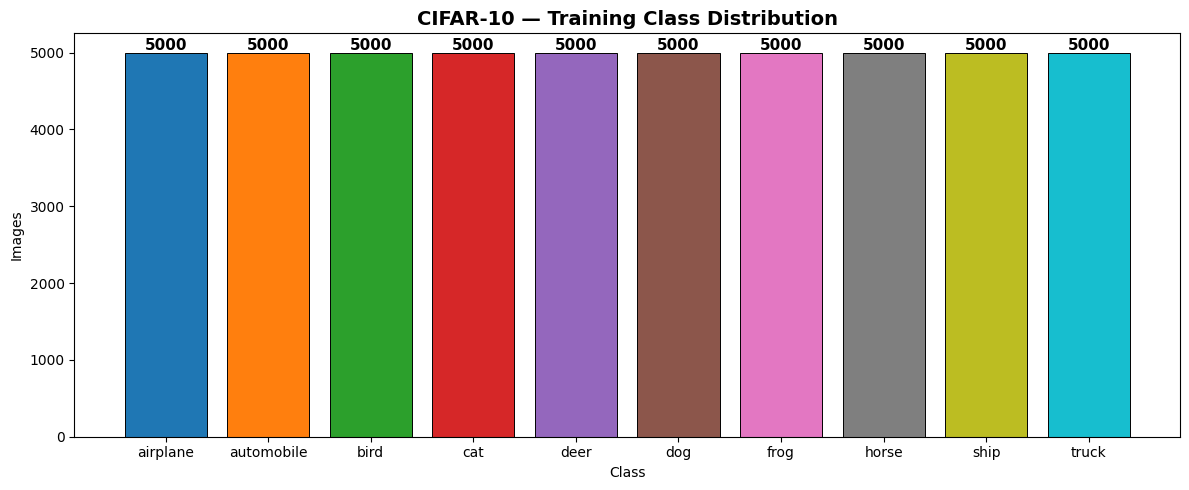

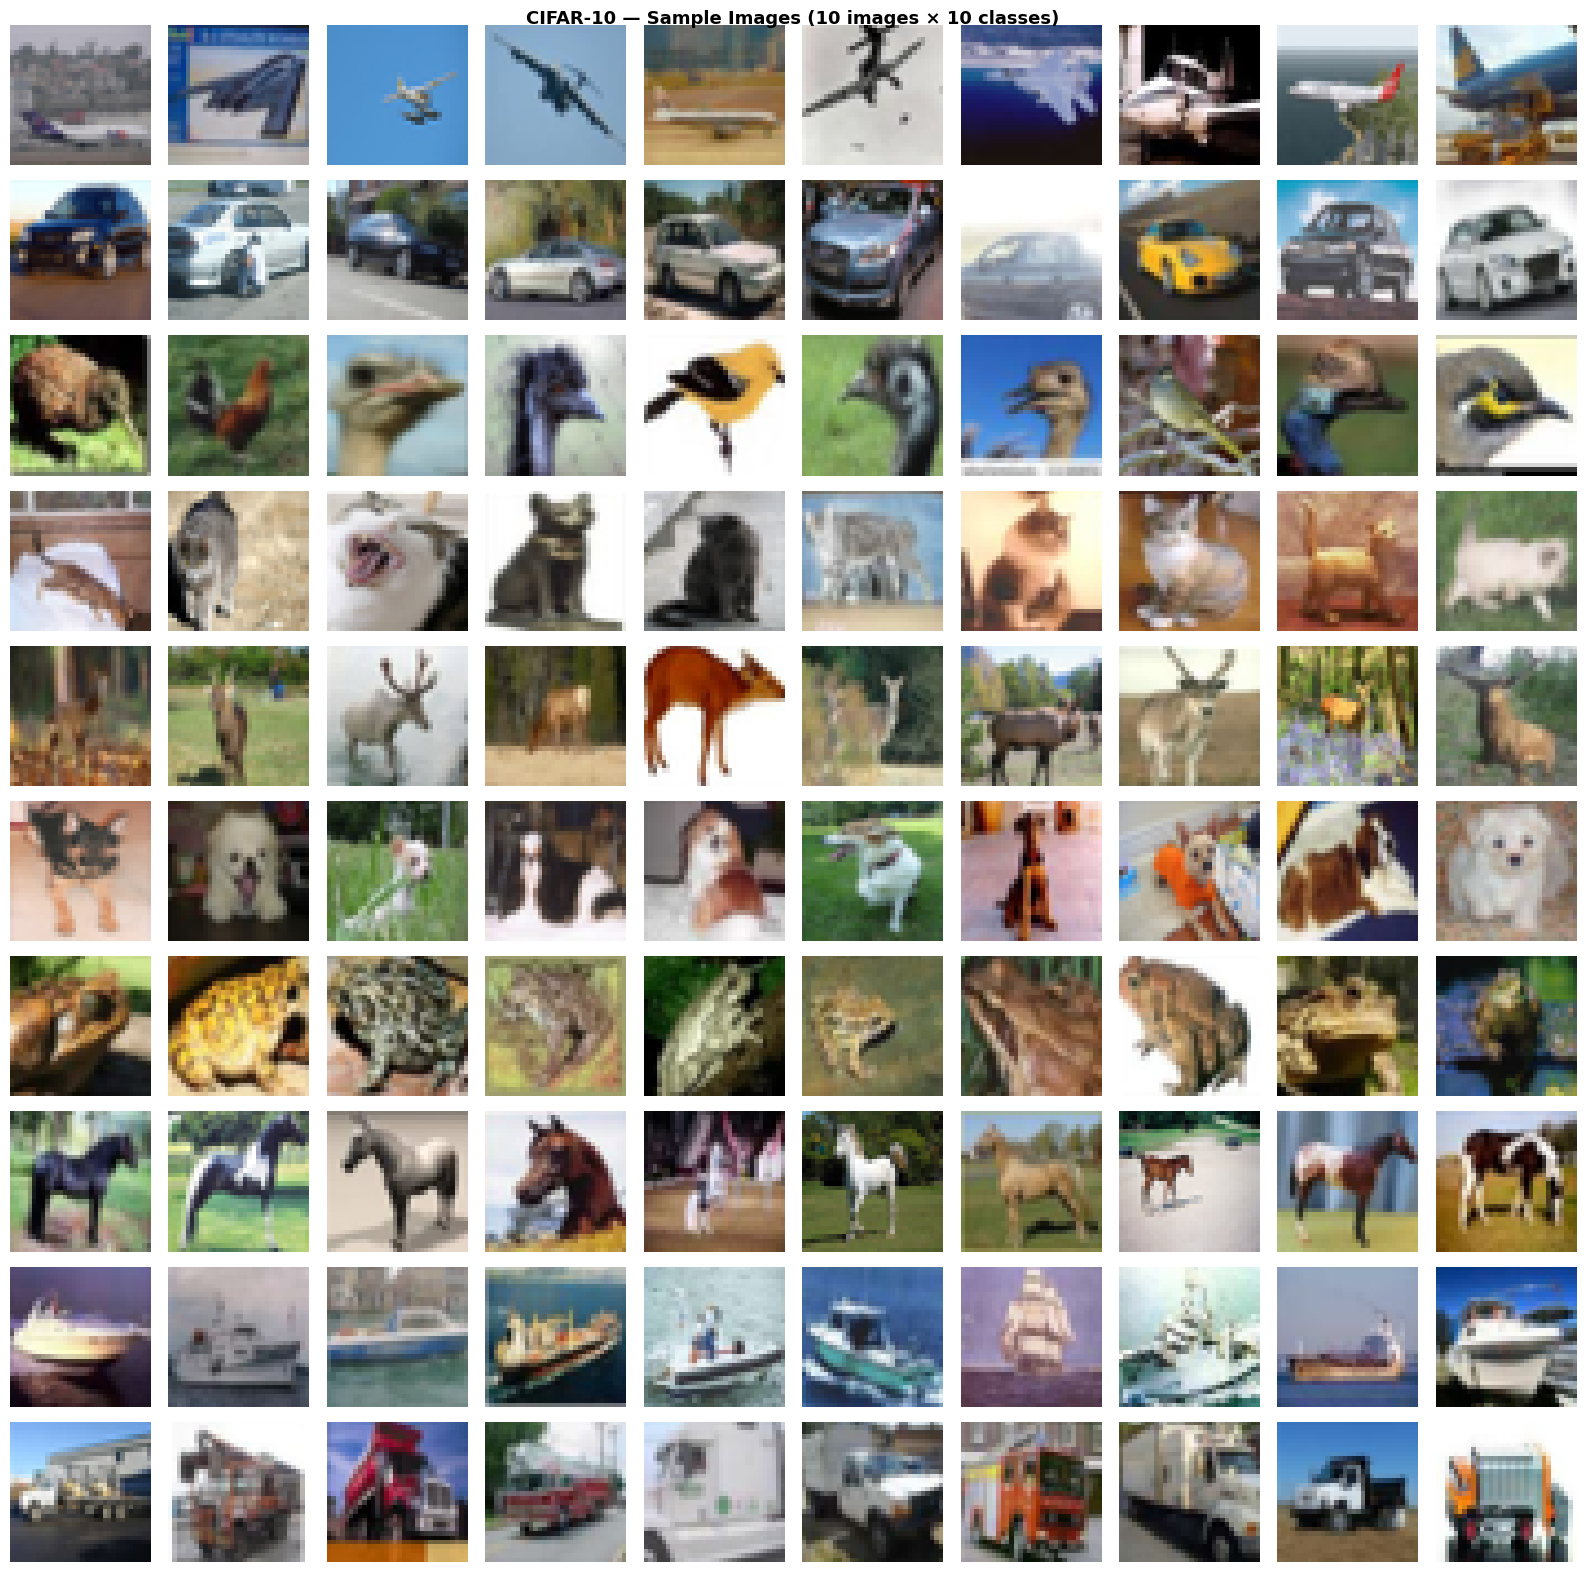

In [6]:
# Class distribution
train_counts = {c: int((y_train==i).sum()) for i,c in enumerate(CLASS_NAMES)}
plt.figure(figsize=(12,5))
colors = plt.cm.tab10.colors
bars = plt.bar(CLASS_NAMES, train_counts.values(), color=colors, edgecolor='k', lw=0.7)
for bar, v in zip(bars, train_counts.values()):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30, str(v),
             ha='center', fontweight='bold', fontsize=11)
plt.title('CIFAR-10 — Training Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class'); plt.ylabel('Images'); plt.tight_layout()
plt.savefig('cifar10_class_dist.png', dpi=150, bbox_inches='tight'); plt.show()

# Sample images (10 per class)
fig, axes = plt.subplots(10, 10, figsize=(16, 16))
for cls_idx in range(10):
    idxs = np.where(y_train.flatten()==cls_idx)[0][:10]
    for j, idx in enumerate(idxs):
        axes[cls_idx][j].imshow(X_train[idx])
        if j==0: axes[cls_idx][j].set_ylabel(CLASS_NAMES[cls_idx], fontsize=9, fontweight='bold')
        axes[cls_idx][j].axis('off')
plt.suptitle('CIFAR-10 — Sample Images (10 images × 10 classes)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('cifar10_samples.png', dpi=150, bbox_inches='tight'); plt.show()

## Step 5: Preprocessing & Augmentation


In [8]:
IMG_SIZE   = 32
BATCH_SIZE = 128
EPOCHS     = 50

# Normalise
X_train_n = X_train.astype('float32') / 255.0
X_test_n  = X_test.astype('float32')  / 255.0
y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

@tf.function
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.pad_to_bounding_box(image, 4, 4, 40, 40)
    image = tf.image.random_crop(image, [32, 32, 3])
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

train_ds = (tf.data.Dataset.from_tensor_slices((X_train_n, y_train_oh))
    .shuffle(50000, seed=42)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((X_test_n, y_test_oh))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE))

print(f'Train batches: {len(train_ds)} | Val batches: {len(val_ds)}')

Train batches: 391 | Val batches: 79


## Step 6: Build Deep CNN


In [9]:
def build_cifar_cnn(num_classes, input_shape=(32, 32, 3)):
    """
    Deep CNN for CIFAR-10 — optimised for 32x32 images
    Uses residual-style feature refinement within each block
    """
    model = Sequential([
        # Block 1 — 64 filters
        Conv2D(64,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4),input_shape=input_shape),
        BatchNormalization(),
        Conv2D(64,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D((2,2)), Dropout(0.25),

        # Block 2 — 128 filters
        Conv2D(128,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Conv2D(128,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D((2,2)), Dropout(0.3),

        # Block 3 — 256 filters
        Conv2D(256,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Conv2D(256,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Conv2D(256,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D((2,2)), Dropout(0.35),

        # Block 4 — 512 filters
        Conv2D(512,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Conv2D(512,(3,3),activation='relu',padding='same',kernel_regularizer=l2(1e-4)),
        BatchNormalization(), Dropout(0.35),

        # Classifier
        GlobalAveragePooling2D(),
        Dense(512,activation='relu',kernel_regularizer=l2(1e-4)),
        BatchNormalization(), Dropout(0.5),
        Dense(256,activation='relu',kernel_regularizer=l2(1e-4)), Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ], name='CIFAR10_CNN')
    return model

model = build_cifar_cnn(NUM_CLASSES)
model.summary()
print(f'Total params: {model.count_params():,}')

Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,682,762 (21.68 MB)

 Trainable params: 5,677,386 (21.66 MB)

 Non-trainable params: 5,376 (21.00 KB)

Total params: 5,682,762


## Step 7: Compile & Train


In [12]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/best_cifar10_cnn.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)
print(f'Best Val Accuracy: {max(history.history["val_accuracy"])*100:.2f}%')

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.2666 - loss: 2.6189 - top3_acc: 0.5972
Epoch 1: val_accuracy improved from None to 0.21240, saving model to /content/best_cifar10_cnn.keras

Epoch 1: finished saving model to /content/best_cifar10_cnn.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 70s 105ms/step - accuracy: 0.3527 - loss: 2.1954 - top3_acc: 0.6967 - val_accuracy: 0.2124 - val_loss: 2.9844 - val_top3_acc: 0.5360 - learning_rate: 0.0010
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5467 - loss: 1.5842 - top3_acc: 0.8426
Epoch 2: val_accuracy improved from 0.21240 to 0.54610, saving model to /content/best_cifar10_cnn.keras

Epoch 2: finished saving model to /content/best_cifar10_cnn.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.5744 - loss: 1.5057 - top3_acc: 0.8574 - val_accuracy: 0.5461 - val_loss: 1.6386 - val_top3_acc: 0.8495 - learning_rate: 0.0010
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6468 - loss

## Step 8: Results & Evaluation


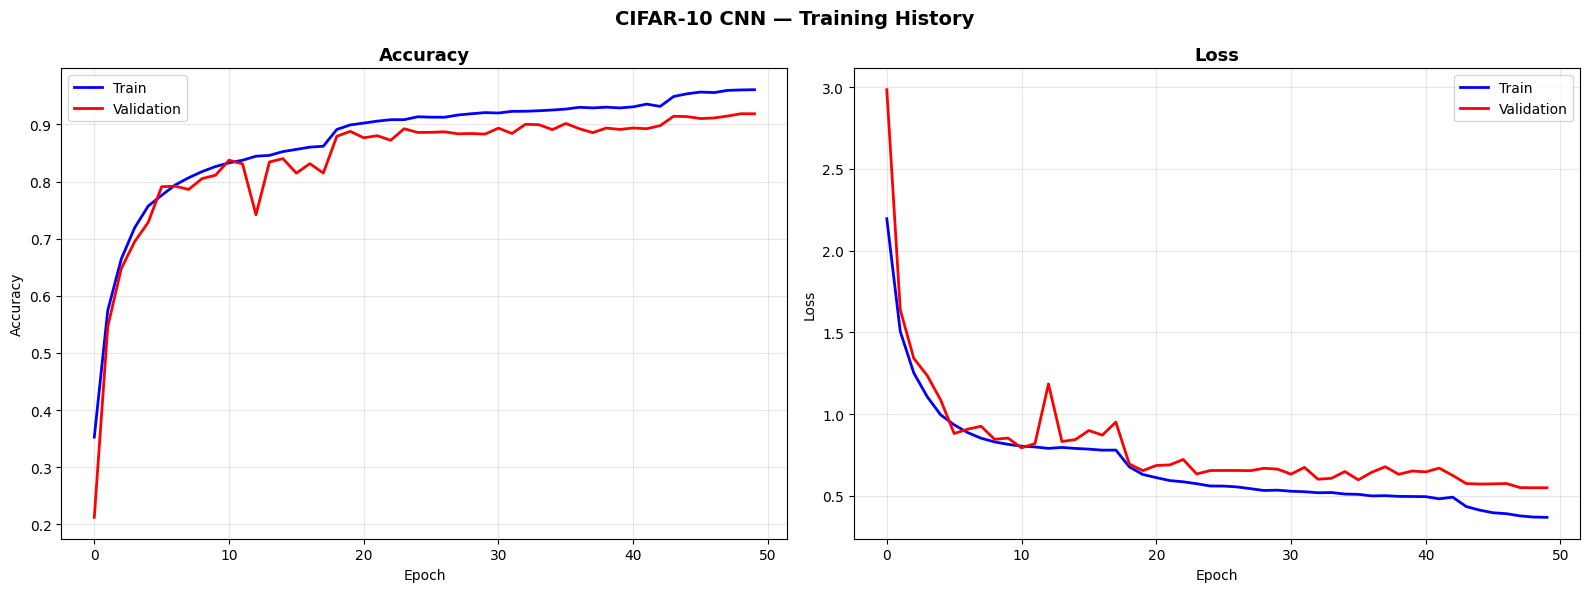

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9186 - loss: 0.5498 - top3_acc: 0.9884
Test Accuracy : 91.86%
Top-3 Accuracy: 98.84%
Test Loss     : 0.5498


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))
for ax, m, label in zip(axes, ['accuracy','loss'], ['Accuracy','Loss']):
    ax.plot(history.history[m],       'b-', label='Train', lw=2)
    ax.plot(history.history[f'val_{m}'],'r-', label='Validation', lw=2)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(label)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('CIFAR-10 CNN — Training History', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('cifar10_history.png', dpi=150, bbox_inches='tight'); plt.show()

res = model.evaluate(X_test_n, y_test_oh, verbose=1)
print(f'Test Accuracy : {res[1]*100:.2f}%')
print(f'Top-3 Accuracy: {res[2]*100:.2f}%')
print(f'Test Loss     : {res[0]:.4f}')

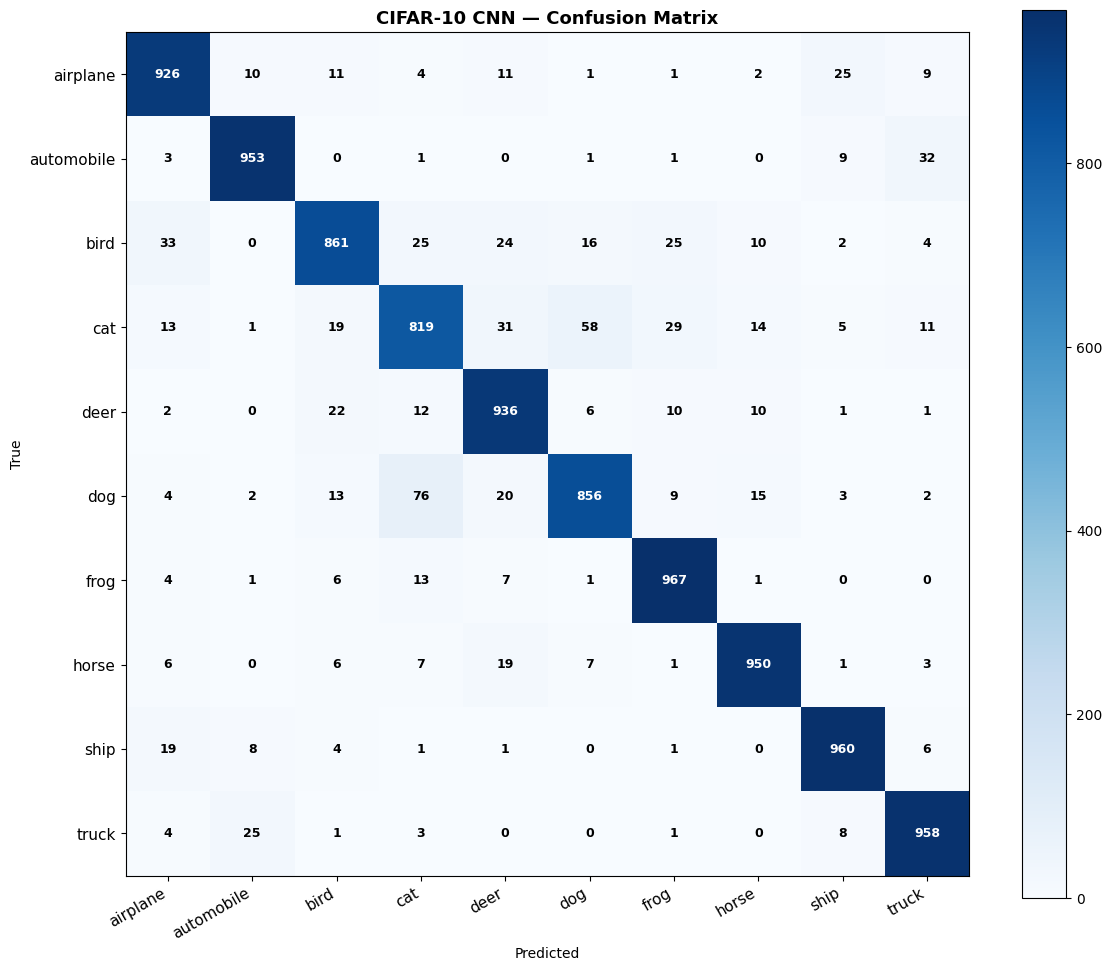

              precision    recall  f1-score   support

    airplane       0.91      0.93      0.92      1000
  automobile       0.95      0.95      0.95      1000
        bird       0.91      0.86      0.89      1000
         cat       0.85      0.82      0.84      1000
        deer       0.89      0.94      0.91      1000
         dog       0.90      0.86      0.88      1000
        frog       0.93      0.97      0.95      1000
       horse       0.95      0.95      0.95      1000
        ship       0.95      0.96      0.95      1000
       truck       0.93      0.96      0.95      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [14]:
# Confusion matrix
y_pred = np.argmax(model.predict(X_test_n, verbose=0), axis=1)
y_true = y_test.flatten()
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(12,10))
im = ax.imshow(cm, cmap='Blues'); plt.colorbar(im)
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=11)
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES, fontsize=11)
thresh = cm.max()/2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=9,fontweight='bold',
                color='white' if cm[i,j]>thresh else 'black')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('CIFAR-10 CNN — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('cifar10_confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

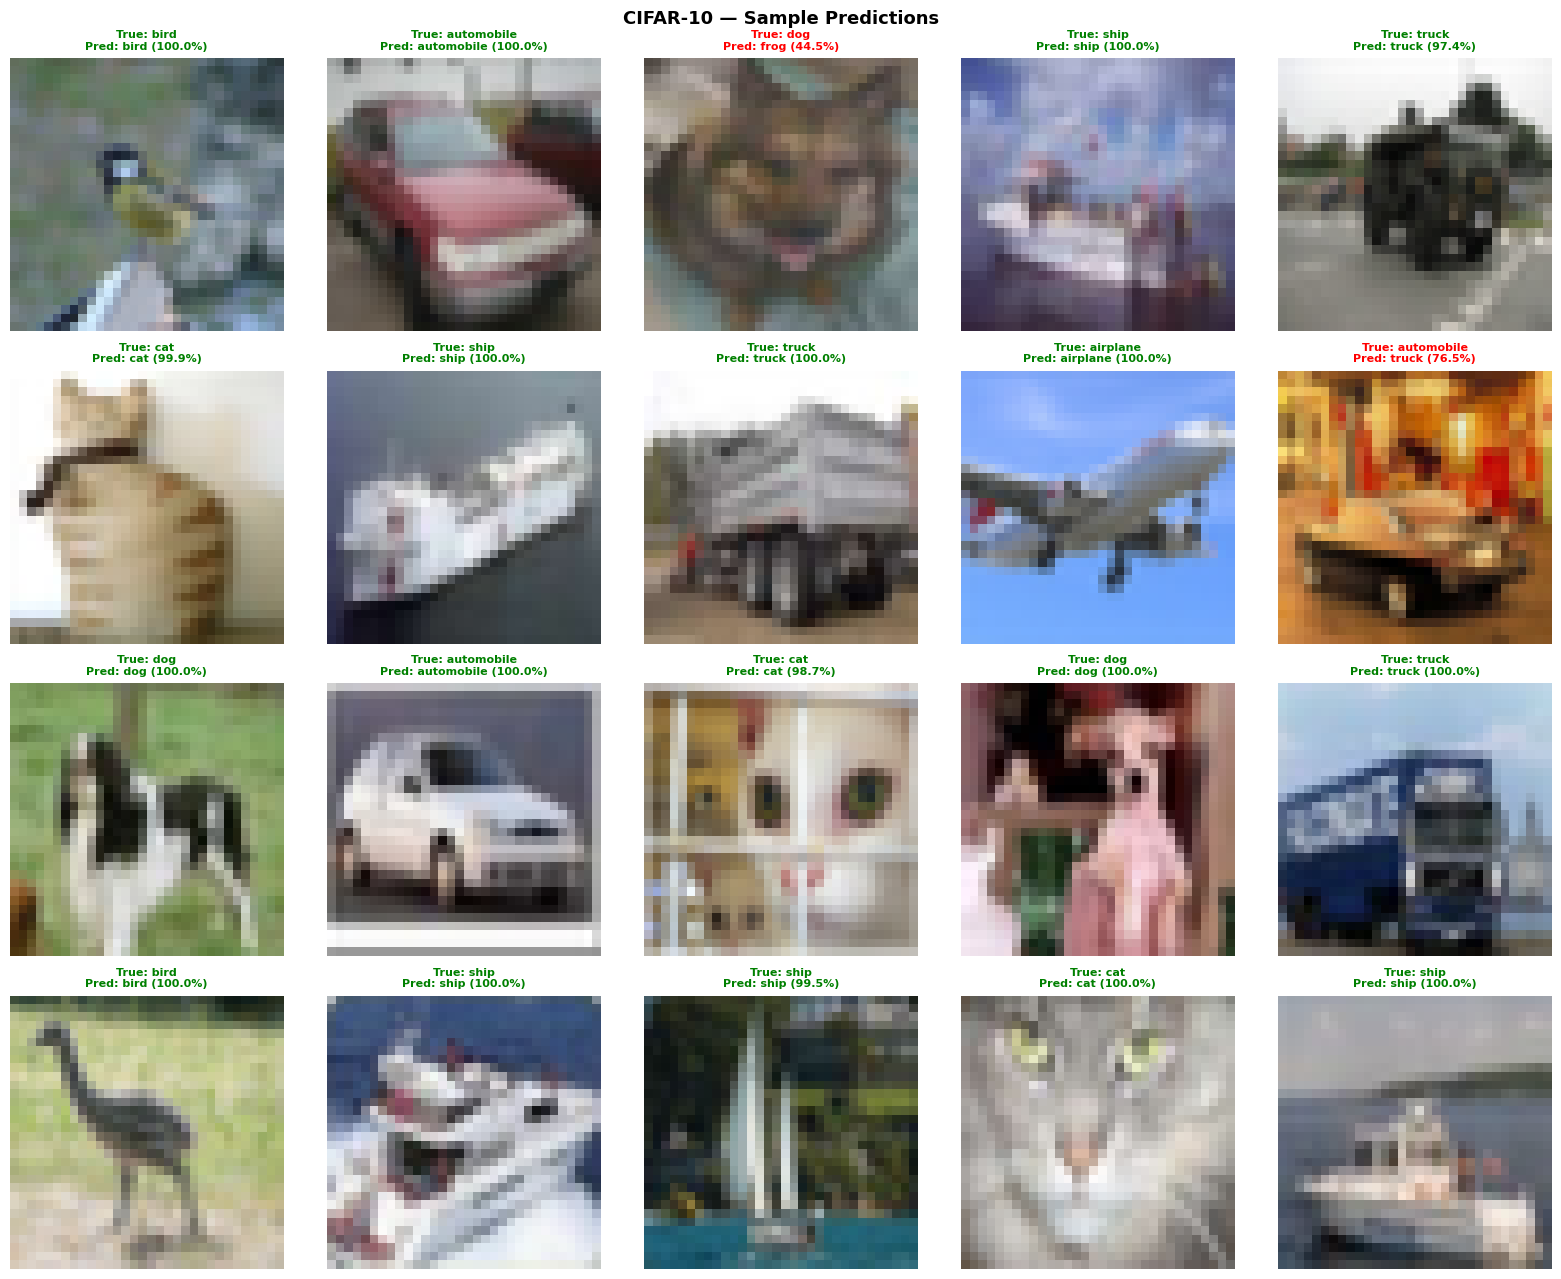

In [15]:
# Sample predictions
idxs = np.random.choice(len(X_test_n), 20, replace=False)
imgs  = X_test_n[idxs]
preds = model.predict(imgs, verbose=0)
fig, axes = plt.subplots(4, 5, figsize=(16,13)); axes = axes.flatten()
for i, idx in enumerate(idxs):
    axes[i].imshow(imgs[i])
    ti = int(y_test[idx]); pi = np.argmax(preds[i]); conf = preds[i][pi]*100
    axes[i].set_title(f'True: {CLASS_NAMES[ti]}\nPred: {CLASS_NAMES[pi]} ({conf:.1f}%)',
                      color='green' if ti==pi else 'red', fontsize=8, fontweight='bold')
    axes[i].axis('off')
plt.suptitle('CIFAR-10 — Sample Predictions', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('cifar10_predictions.png', dpi=150, bbox_inches='tight'); plt.show()

## Summary


In [16]:
print('='*55)
print('  IMAGE CLASSIFICATION CNN (CIFAR-10) — SUMMARY')
print('='*55)
print('  Name        : Ayush Ranjan')
print('  Roll No     : 23MIP10135')
print('  Institute   : VIT Bhopal')
print('  Dataset     : CIFAR-10 (60,000 images, 10 classes)')
print(f'  Classes     : {", ".join(CLASS_NAMES)}')
print(f'  Image Size  : 32x32')
print('  Architecture: Deep CNN — 4 conv blocks + GAP')
print(f'  Parameters  : {model.count_params():,}')
print(f'  Test Accuracy: {res[1]*100:.2f}%')
print(f'  Top-3 Acc   : {res[2]*100:.2f}%')
print('='*55)

  IMAGE CLASSIFICATION CNN (CIFAR-10) — SUMMARY
  Name        : Ayush Ranjan
  Roll No     : 23MIP10135
  Institute   : VIT Bhopal
  Dataset     : CIFAR-10 (60,000 images, 10 classes)
  Classes     : airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
  Image Size  : 32x32
  Architecture: Deep CNN — 4 conv blocks + GAP
  Parameters  : 5,682,762
  Test Accuracy: 91.86%
  Top-3 Acc   : 98.84%
